In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.util import Util

In [71]:
u = Util('configs_pypyr')
pums_hh = u.get_table('seed_households')

In [72]:
for table in u.settings['input_table_list']:
    if table['tablename'] == 'regional_controls':
        regional_controls_filename = table['filename'].split('.')[0]
regional_controls_filename

'REMI_OFM_v2022_Medium'

In [73]:
# compute income quartiles using household survey weights (WGTP)
weighted_income = pums_hh[['HINCP', 'WGTP']].dropna().copy()
weighted_income = weighted_income.loc[weighted_income['WGTP'] > 0].sort_values('HINCP')

cum_weight_share = weighted_income['WGTP'].cumsum() / weighted_income['WGTP'].sum()
weighted_cutoffs = np.interp([0.25, 0.5, 0.75], cum_weight_share, weighted_income['HINCP'])

# shared bins/labels derived from weighted PUMS quartile cutoffs
income_bin_edges = [-np.inf, *weighted_cutoffs.tolist(), np.inf]

# display labels rounded to nearest thousand (e.g. $60k)
cutoff_k = np.rint(weighted_cutoffs / 1000).astype(int)
income_bin_labels = [
    f"up to ${cutoff_k[0]:,}k",
    f"${cutoff_k[0]:,}k to ${cutoff_k[1]:,}k",
    f"${cutoff_k[1]:,}k to ${cutoff_k[2]:,}k",
    f"${cutoff_k[2]:,}k+",
]

pums_hh['income_quartile'] = pd.cut(
    pums_hh['HINCP'],
    bins=income_bin_edges,
    labels=[1, 2, 3, 4],
    include_lowest=True,
 ).astype('Int64')

# create a dictionary of the weighted cutoff points for the income quartiles
income_quartiles = {i + 1: cutoff for i, cutoff in enumerate(weighted_cutoffs)}
print('Weighted income quartile cutoffs:')
for quartile, cutoff in income_quartiles.items():
    print(f'Quartile {quartile}: ${cutoff:,.0f}')
print('Income bin labels:', income_bin_labels)

Weighted income quartile cutoffs:
Quartile 1: $60,139
Quartile 2: $114,602
Quartile 3: $199,399
Income bin labels: ['up to $60k', '$60k to $115k', '$115k to $199k', '$199k+']


In [74]:
hh = pd.read_csv('output/synthetic_households.csv')

In [75]:
# categorize households into income groups using weighted PUMS bin edges/labels
hh['income'] = pd.cut(
    hh['HINCP'],
    bins=income_bin_edges,
    labels=income_bin_labels,
    include_lowest=True,
)

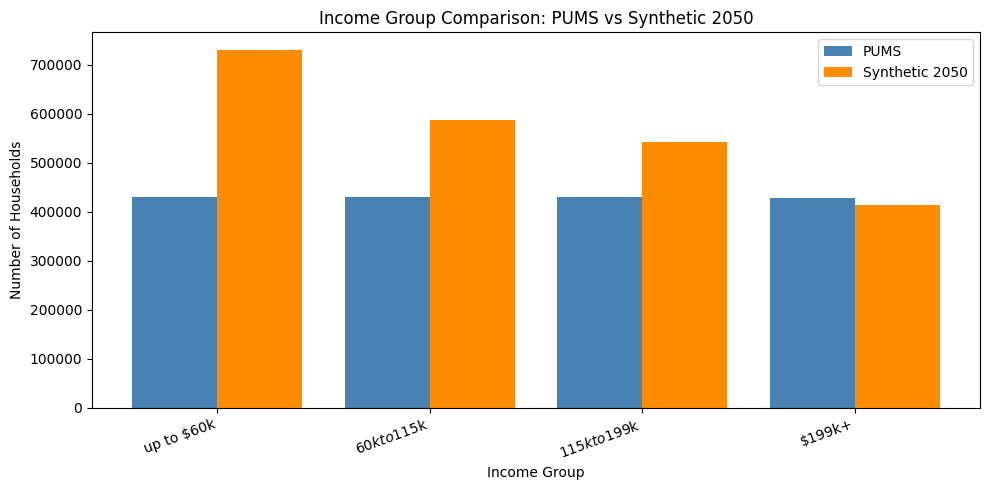

In [76]:
# compare PUMS vs synthetic 2050 income distributions using common weighted PUMS bins
income_categories = income_bin_labels
pums_income_counts = pums_hh.groupby('income_quartile')['WGTP'].sum().reindex([1, 2, 3, 4]).values
synthetic_income_counts = hh['income'].value_counts().reindex(income_categories, fill_value=0).values

x = np.arange(len(income_categories))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, pums_income_counts, width=width, label='PUMS', color='steelblue')
plt.bar(x + width / 2, synthetic_income_counts, width=width, label='Synthetic 2050', color='darkorange')
plt.xticks(x, income_categories, rotation=20, ha='right')
plt.xlabel('Income Group')
plt.ylabel('Number of Households')
plt.title('Income Group Comparison: PUMS vs Synthetic 2050')
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
# cap household size at 7
pums_hh['hhsz'] = np.where(pums_hh['NP']>7,7,pums_hh['NP'])
hh['hhsz'] = np.where(hh['NP']>7,7,hh['NP'])

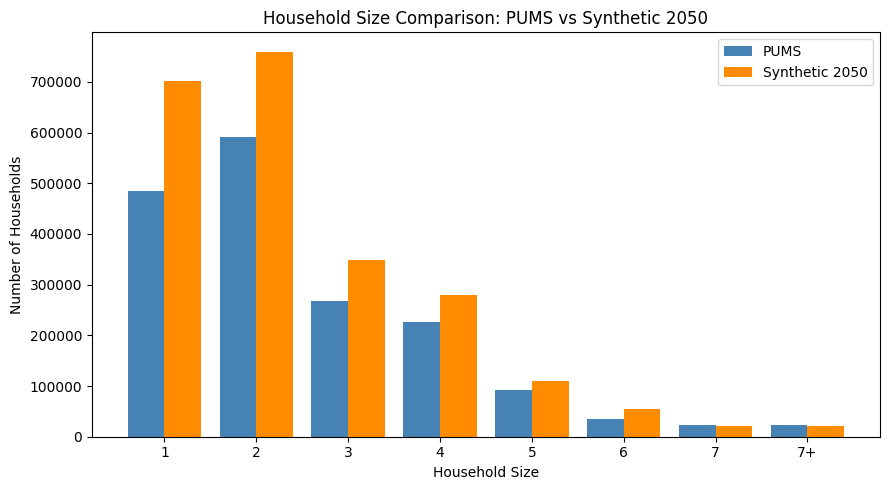

In [78]:
# compare PUMS vs synthetic 2050 household size distributions
size_categories = list(range(1, 8)) + [7]
size_labels = [str(i) for i in range(1, 8)] + ['7+']
pums_size_counts = pums_hh.groupby('hhsz')['WGTP'].sum().reindex(size_categories, fill_value=0).values
synthetic_size_counts = hh.groupby('hhsz').size().reindex(size_categories, fill_value=0).values

x = np.arange(len(size_categories))
width = 0.4

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, pums_size_counts, width=width, label='PUMS', color='steelblue')
plt.bar(x + width / 2, synthetic_size_counts, width=width, label='Synthetic 2050', color='darkorange')
plt.xticks(x, size_labels)
plt.xlabel('Household Size')
plt.ylabel('Number of Households')
plt.title('Household Size Comparison: PUMS vs Synthetic 2050')
plt.legend()
plt.tight_layout()
plt.show()

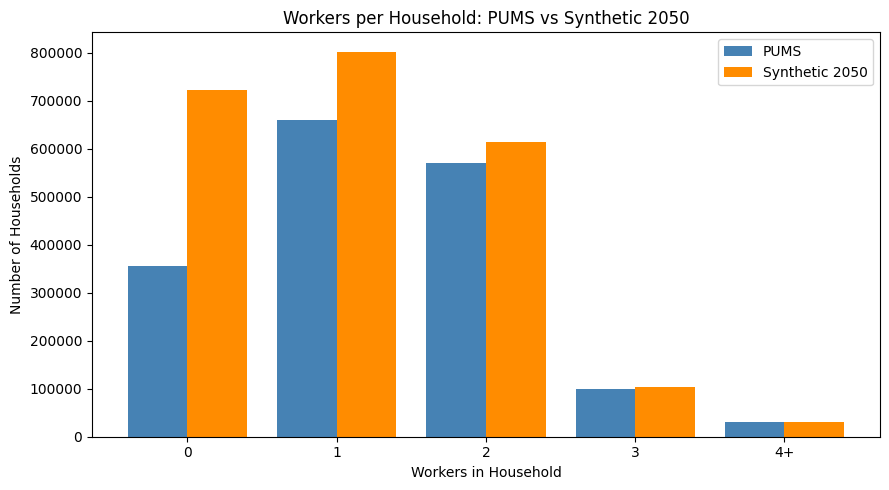

In [79]:
# compare PUMS vs synthetic 2050 number of workers in household
pums_hh['workers'] = np.where(pums_hh['worker_count'] > 4, 4, pums_hh['worker_count'])
hh['workers'] = np.where(hh['worker_count'] > 4, 4, hh['worker_count'])
worker_categories = [0, 1, 2, 3, 4]
worker_labels = ['0', '1', '2', '3', '4+']
pums_worker_counts = pums_hh.groupby('workers')['WGTP'].sum().reindex(worker_categories, fill_value=0).values
synthetic_worker_counts = hh.groupby('workers').size().reindex(worker_categories, fill_value=0).values

x = np.arange(len(worker_categories))
width = 0.4

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, pums_worker_counts, width=width, label='PUMS', color='steelblue')
plt.bar(x + width / 2, synthetic_worker_counts, width=width, label='Synthetic 2050', color='darkorange')
plt.xticks(x, worker_labels)
plt.xlabel('Workers in Household')
plt.ylabel('Number of Households')
plt.title('Workers per Household: PUMS vs Synthetic 2050')
plt.legend()
plt.tight_layout()
plt.show()

Saved summary chart image to: output\results_summaries\REMI_OFM_v2022_Medium.png


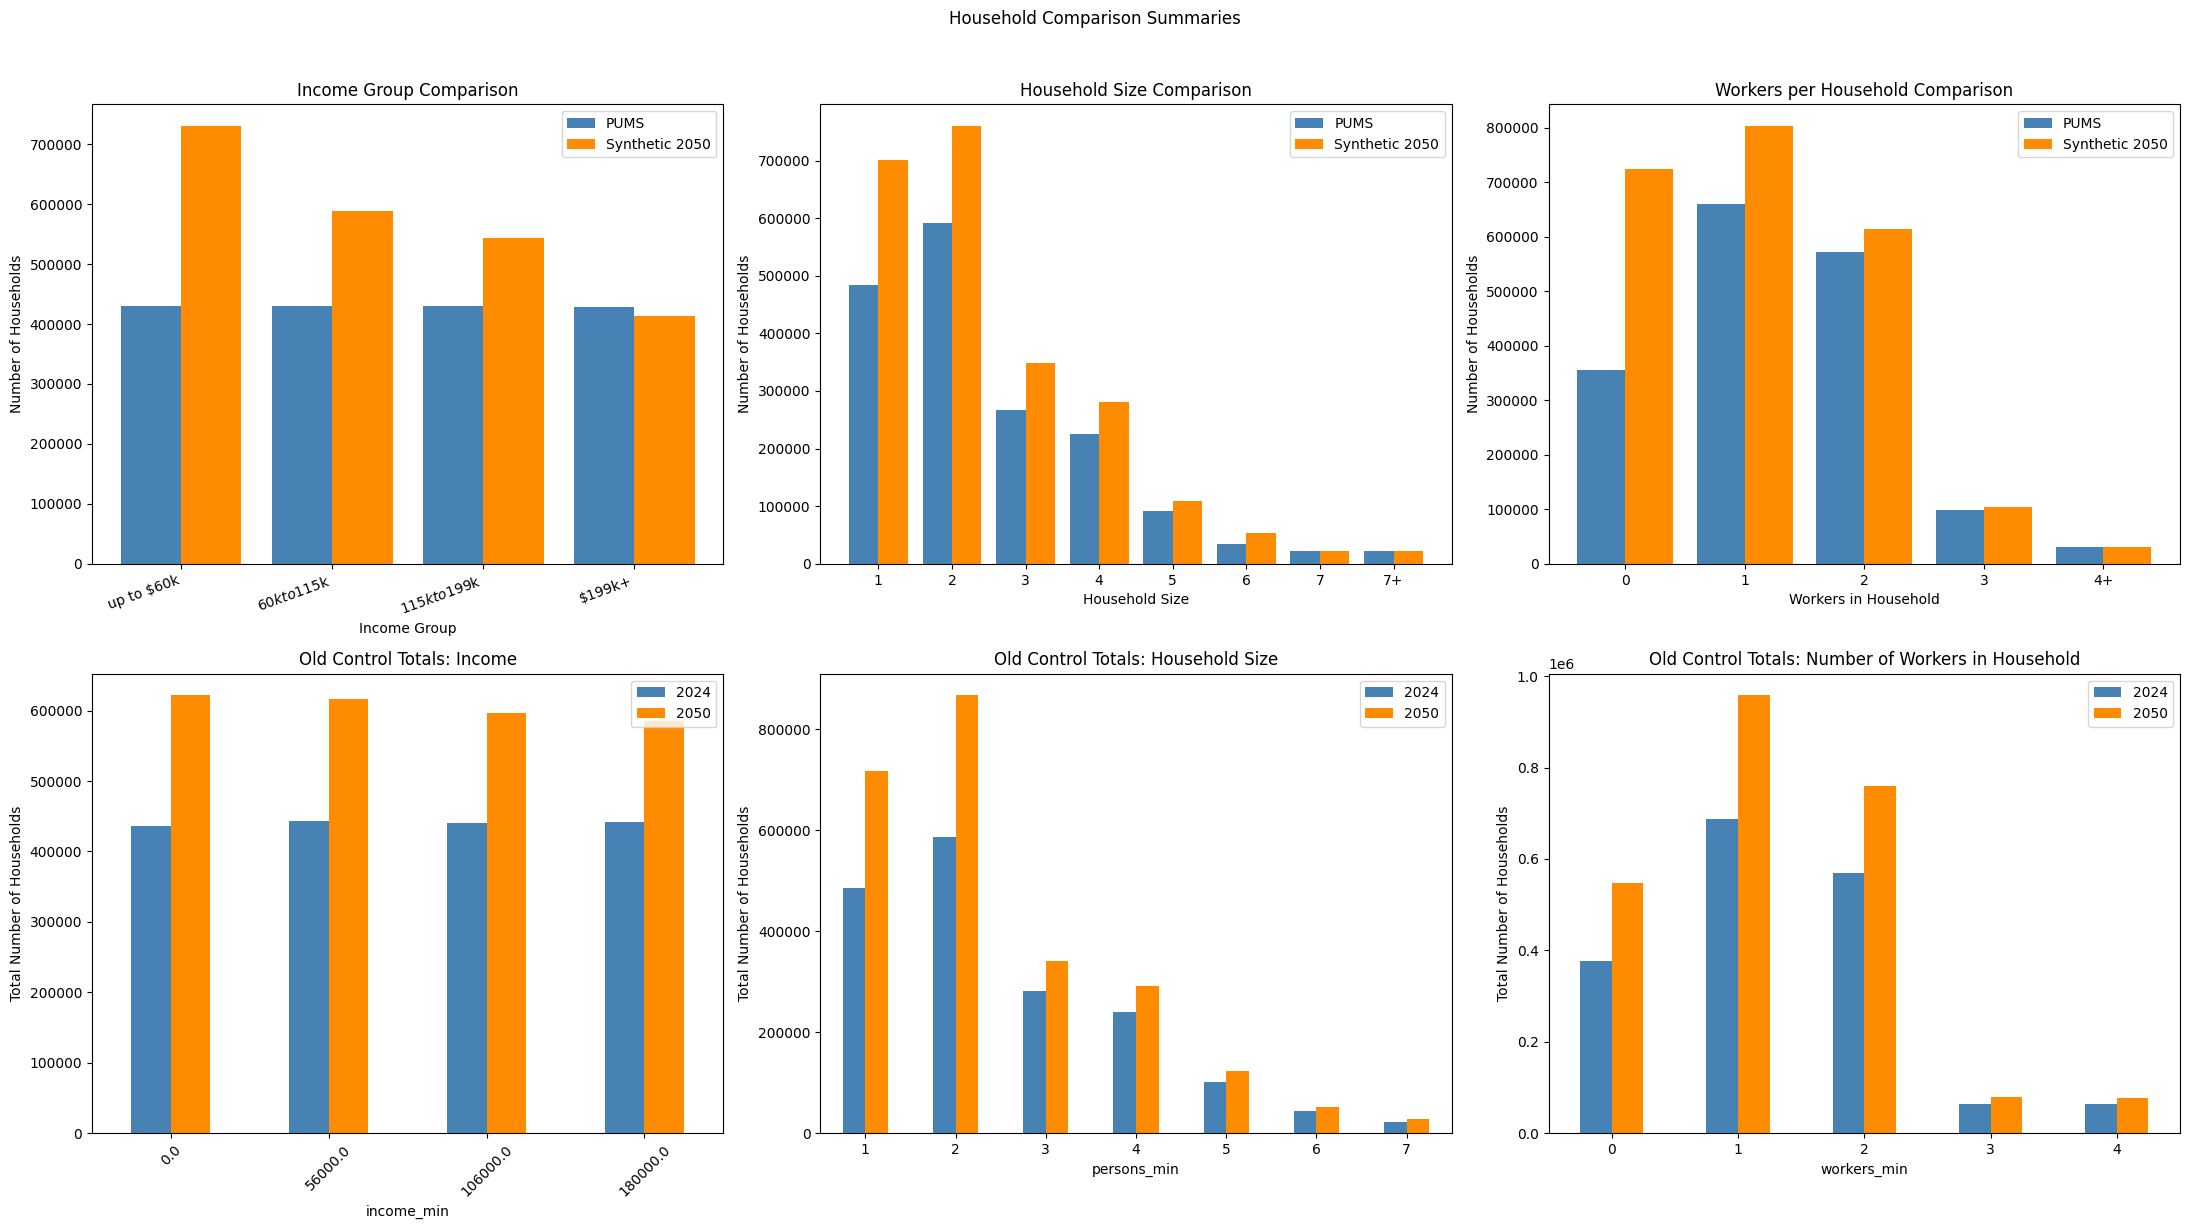

In [85]:
# save the six comparison charts as one image file
from pathlib import Path

if 'ct' not in globals():
    with pd.HDFStore('C:/Users/JKolberg/PythonProjects/urbansim2/data/psrc_base_year_2023_py3.h5') as store:
        ct = store['/annual_household_control_totals']

income_categories = income_bin_labels
pums_income_counts = pums_hh.groupby('income_quartile')['WGTP'].sum().reindex([1, 2, 3, 4], fill_value=0).values
synthetic_income_counts = hh['income'].value_counts().reindex(income_categories, fill_value=0).values

size_categories = list(range(1, 8)) + [7]
size_labels = [str(i) for i in range(1, 8)] + ['7+']
pums_size_counts = pums_hh.groupby('hhsz')['WGTP'].sum().reindex(size_categories, fill_value=0).values
synthetic_size_counts = hh.groupby('hhsz').size().reindex(size_categories, fill_value=0).values

worker_categories = [0, 1, 2, 3, 4]
worker_labels = ['0', '1', '2', '3', '4+']
pums_worker_counts = pums_hh.groupby('workers')['WGTP'].sum().reindex(worker_categories, fill_value=0).values
synthetic_worker_counts = hh.groupby('workers').size().reindex(worker_categories, fill_value=0).values

income_2024 = ct.loc[ct.index == 2024].groupby('income_min')['total_number_of_households'].sum()
income_2050 = ct.loc[ct.index == 2050].groupby('income_min')['total_number_of_households'].sum()
income_compare = pd.DataFrame({'2024': income_2024, '2050': income_2050}).fillna(0).sort_index()

persons_2024 = ct.loc[ct.index == 2024].groupby('persons_min')['total_number_of_households'].sum()
persons_2050 = ct.loc[ct.index == 2050].groupby('persons_min')['total_number_of_households'].sum()
persons_compare = pd.DataFrame({'2024': persons_2024, '2050': persons_2050}).fillna(0).sort_index()

workers_2024 = ct.loc[ct.index == 2024].groupby('workers_min')['total_number_of_households'].sum()
workers_2050 = ct.loc[ct.index == 2050].groupby('workers_min')['total_number_of_households'].sum()
workers_compare = pd.DataFrame({'2024': workers_2024, '2050': workers_2050}).fillna(0).sort_index()

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
width = 0.4

x_income = np.arange(len(income_categories))
axes[0, 0].bar(x_income - width / 2, pums_income_counts, width=width, label='PUMS', color='steelblue')
axes[0, 0].bar(x_income + width / 2, synthetic_income_counts, width=width, label='Synthetic 2050', color='darkorange')
axes[0, 0].set_xticks(x_income)
axes[0, 0].set_xticklabels(income_categories, rotation=20, ha='right')
axes[0, 0].set_xlabel('Income Group')
axes[0, 0].set_ylabel('Number of Households')
axes[0, 0].set_title('Income Group Comparison')
axes[0, 0].legend()

x_size = np.arange(len(size_categories))
axes[0, 1].bar(x_size - width / 2, pums_size_counts, width=width, label='PUMS', color='steelblue')
axes[0, 1].bar(x_size + width / 2, synthetic_size_counts, width=width, label='Synthetic 2050', color='darkorange')
axes[0, 1].set_xticks(x_size)
axes[0, 1].set_xticklabels(size_labels)
axes[0, 1].set_xlabel('Household Size')
axes[0, 1].set_ylabel('Number of Households')
axes[0, 1].set_title('Household Size Comparison')
axes[0, 1].legend()

x_workers = np.arange(len(worker_categories))
axes[0, 2].bar(x_workers - width / 2, pums_worker_counts, width=width, label='PUMS', color='steelblue')
axes[0, 2].bar(x_workers + width / 2, synthetic_worker_counts, width=width, label='Synthetic 2050', color='darkorange')
axes[0, 2].set_xticks(x_workers)
axes[0, 2].set_xticklabels(worker_labels)
axes[0, 2].set_xlabel('Workers in Household')
axes[0, 2].set_ylabel('Number of Households')
axes[0, 2].set_title('Workers per Household Comparison')
axes[0, 2].legend()

income_compare.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'darkorange'])
axes[1, 0].set_xlabel('income_min')
axes[1, 0].set_ylabel('Total Number of Households')
axes[1, 0].set_title('Old Control Totals: Income')
axes[1, 0].tick_params(axis='x', rotation=45)

persons_compare.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'darkorange'])
axes[1, 1].set_xlabel('persons_min')
axes[1, 1].set_ylabel('Total Number of Households')
axes[1, 1].set_title('Old Control Totals: Household Size')
axes[1, 1].tick_params(axis='x', rotation=0)

workers_compare.plot(kind='bar', ax=axes[1, 2], color=['steelblue', 'darkorange'])
axes[1, 2].set_xlabel('workers_min')
axes[1, 2].set_ylabel('Total Number of Households')
axes[1, 2].set_title('Old Control Totals: Number of Workers in Household')
axes[1, 2].tick_params(axis='x', rotation=0)

output_dir = Path('output') / 'results_summaries'
output_dir.mkdir(parents=True, exist_ok=True)
file_stem = globals().get('regional_controls_filename', 'regional_controls_summary')
save_path = output_dir / f"{file_stem}.png"

fig.suptitle('Household Comparison Summaries', y=1.02)
fig.tight_layout()
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved summary chart image to: {save_path}")
plt.show()